In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import os
if os.path.exists('salary.csv.zip'):
    !unzip -o salary.csv.zip

# 1. โหลดข้อมูล
df = pd.read_csv('salary.csv')

# ตรวจสอบข้อมูลเบื้องต้น
print("--- ข้อมูล 5 แถวแรก ---")
display(df.head())
print("\n--- รายละเอียดคอลัมน์ ---")
df.info()

# 2. จัดการช่องว่างและค่าว่าง
# เนื่องจากข้อมูลชุดนี้มักมีช่องว่างติดมา เช่น ' <=50K' ให้ตัดช่องว่างออกก่อน
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# เปลี่ยน '?' เป็น NaN เพื่อให้ง่ายต่อการนับและลบ
df.replace('?', np.nan, inplace=True)

print("\n--- จำนวนค่าว่างในแต่ละคอลัมน์ ---")
print(df.isnull().sum())

# เลือกจัดการค่าว่าง (ในที่นี้แนะนำให้ลบแถวที่มีค่าว่างออกเพื่อให้ข้อมูลสะอาด)
df.dropna(inplace=True)
print(f"\nจำนวนข้อมูลหลังลบค่าว่าง: {len(df)} แถว")

Archive:  salary.csv.zip
  inflating: salary.csv              
--- ข้อมูล 5 แถวแรก ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



--- รายละเอียดคอลัมน์ ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  salary          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

--- จำนวนค่าว่างในแต่ละคอลัมน์ ---
age                  0
workcla

# **Data Cleaning**

In [12]:
df = df.replace(' ?', np.nan)
df = df.dropna()

# **Exploratory Data Analysis (EDA)**

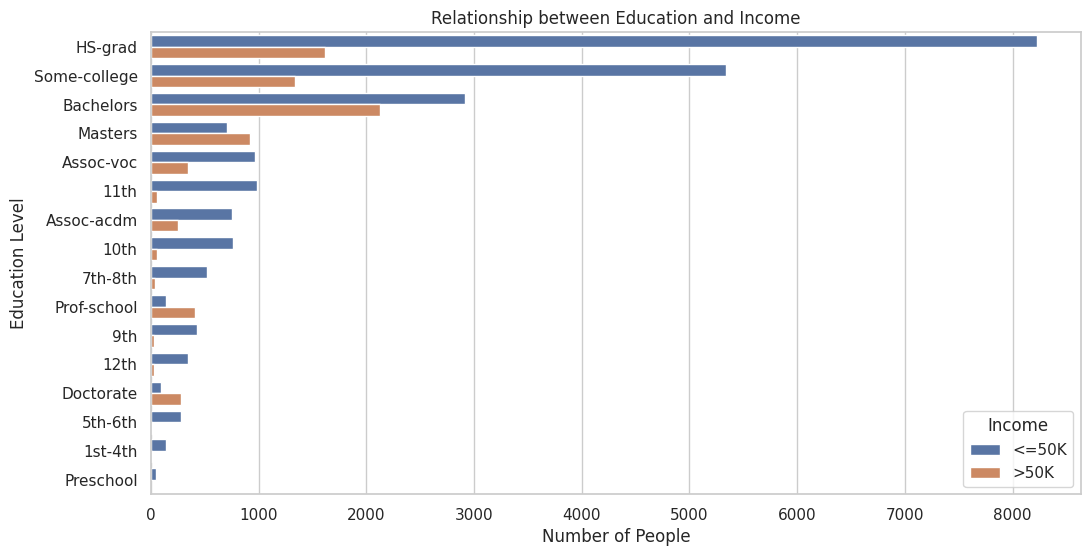

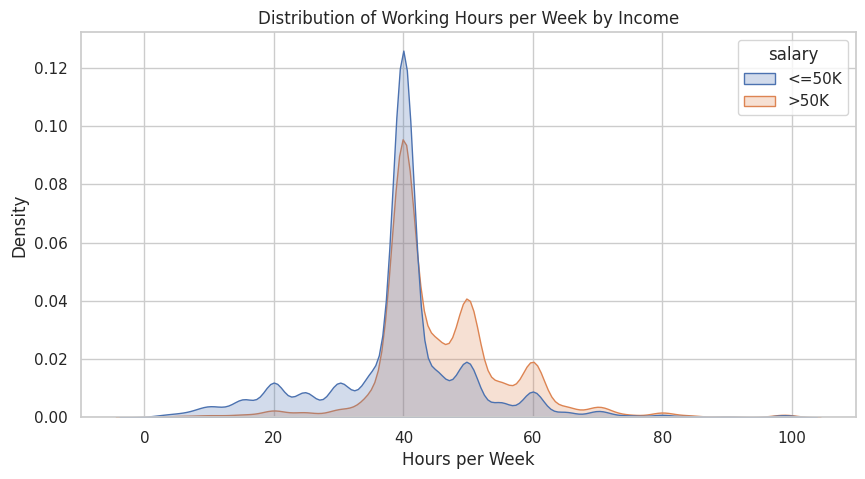

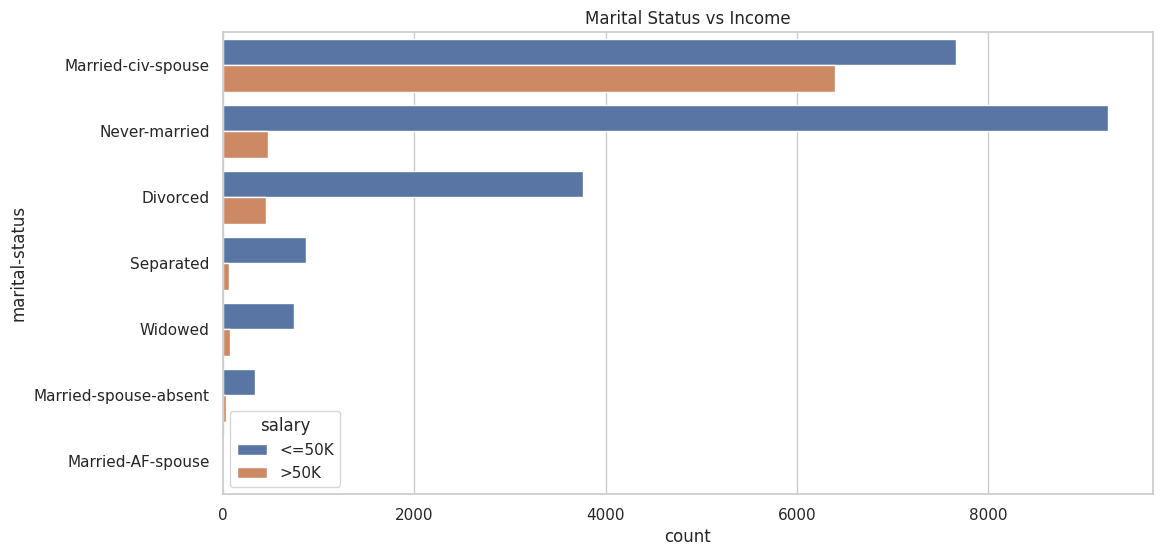

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")

# 1. วิเคราะห์ความสัมพันธ์ระหว่างการศึกษา (Education) และรายได้
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='education', hue='salary', order=df['education'].value_counts().index)
plt.title('Relationship between Education and Income')
plt.xlabel('Number of People')
plt.ylabel('Education Level')
plt.legend(title='Income', loc='lower right')
plt.show()

# 2. วิเคราะห์ชั่วโมงการทำงาน (Hours per week) แยกตามรายได้
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='hours-per-week', hue='salary', fill=True, common_norm=False)
plt.title('Distribution of Working Hours per Week by Income')
plt.xlabel('Hours per Week')
plt.show()

# 3. วิเคราะห์ความสัมพันธ์ระหว่างสถานภาพสมรส (Marital Status) และรายได้
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='marital-status', hue='salary', order=df['marital-status'].value_counts().index)
plt.title('Marital Status vs Income')
plt.show()

# **Data Preprocessing (เตรียมข้อมูลด้วย Pipeline)**

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. แยก Features และ Target
X = df.drop('salary', axis=1) # เปลี่ยน 'income' เป็น 'salary'
y = df['salary'].apply(lambda x: 1 if x.strip() == '>50K' else 0) # เปลี่ยน 'income' เป็น 'salary'

# 2. ระบุกลุ่มคอลัมน์
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 3. สร้าง Pipeline สำหรับจัดการข้อมูล
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("เตรียมข้อมูลเรียบร้อย!")

เตรียมข้อมูลเรียบร้อย!


# **เทรนโมเดลเบื้องต้น**

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. รวม Preprocessor เข้ากับ Model เป็น Pipeline เดียว
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 2. ลองเทรน (Fit) ข้อมูล
full_pipeline.fit(X_train, y_train)

# 3. ทดสอบทำนายผล
y_pred = full_pipeline.predict(X_test)
print("--- ผลการประเมินโมเดลเบื้องต้น ---")
print(classification_report(y_test, y_pred))

--- ผลการประเมินโมเดลเบื้องต้น ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4503
           1       0.74      0.64      0.69      1530

    accuracy                           0.85      6033
   macro avg       0.81      0.78      0.79      6033
weighted avg       0.85      0.85      0.85      6033



# **Optuna หาค่าที่ดีที่สุด**

In [20]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # ให้ Optuna ช่วยเลือกค่าที่ดีที่สุด
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 5, 30)

    # สร้างโมเดลด้วยค่าที่สุ่มมา
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42))
    ])

    # วัดคะแนนด้วย Cross Validation
    return cross_val_score(clf, X_train, y_train, cv=3).mean()

# เริ่มการจูน
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # ลองสุ่ม 10 ครั้ง (เพิ่มได้ถ้ามีเวลา)

print("ค่าที่ดีที่สุด:", study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00


[I 2026-03-24 17:43:20,736] A new study created in memory with name: no-name-82397031-2f0b-4399-988f-85313ff7b467
[I 2026-03-24 17:44:22,116] Trial 0 finished with value: 0.85627253512371 and parameters: {'n_estimators': 200, 'max_depth': 25}. Best is trial 0 with value: 0.85627253512371.
[I 2026-03-24 17:47:08,598] Trial 1 finished with value: 0.8548219984251316 and parameters: {'n_estimators': 479, 'max_depth': 30}. Best is trial 0 with value: 0.85627253512371.
[I 2026-03-24 17:47:33,781] Trial 2 finished with value: 0.8524596958017323 and parameters: {'n_estimators': 371, 'max_depth': 9}. Best is trial 0 with value: 0.85627253512371.
[I 2026-03-24 17:48:27,562] Trial 3 finished with value: 0.8571428571428572 and parameters: {'n_estimators': 302, 'max_depth': 16}. Best is trial 3 with value: 0.8571428571428572.
[I 2026-03-24 17:49:36,584] Trial 4 finished with value: 0.8575572961995938 and parameters: {'n_estimators': 431, 'max_depth': 15}. Best is trial 4 with value: 0.8575572961995

ค่าที่ดีที่สุด: {'n_estimators': 376, 'max_depth': 21}


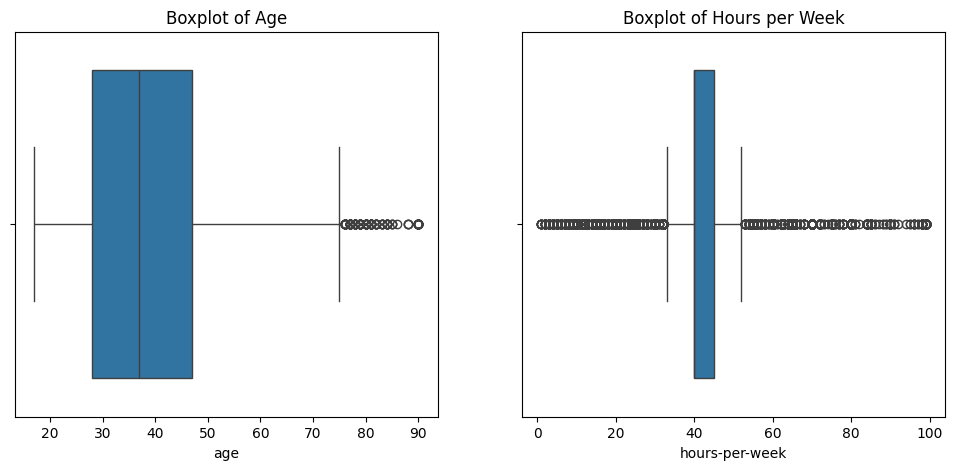

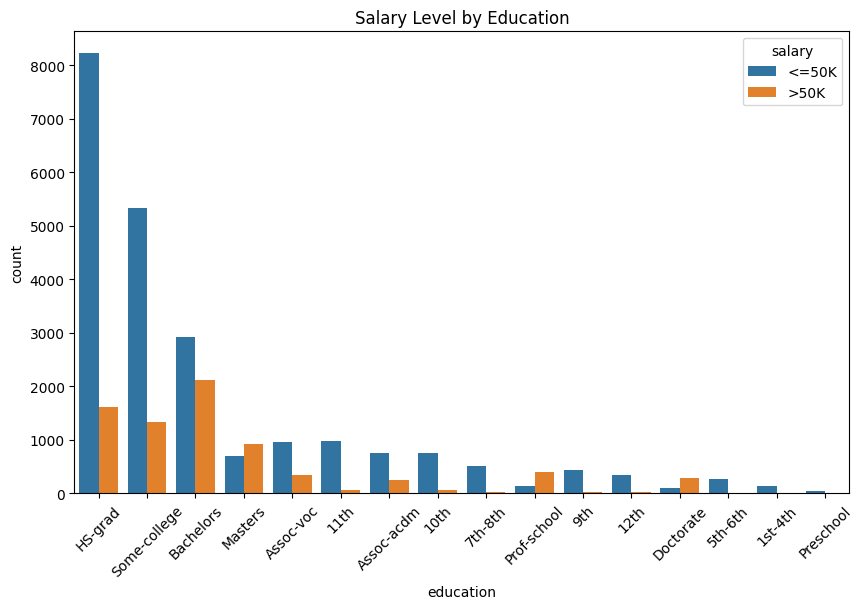

In [7]:
# 3. ตรวจสอบ Outlier ด้วย Boxplot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['hours-per-week'])
plt.title('Boxplot of Hours per Week')
plt.show()

# ฟังก์ชันจัดการ Outlier ด้วยวิธี IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# ลองจัดการ Outlier ในคอลัมน์ hours-per-week (ถ้าต้องการ)
# df = remove_outliers(df, 'hours-per-week')

# --- แถม: ส่วน EDA เพื่อเอาไปใส่ใน Slide ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='education', hue='salary', order=df['education'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Salary Level by Education')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# ตัดคอลัมน์เป้าหมายออกเพื่อสร้าง X และ y
X = df.drop('salary', axis=1)
y = df['salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  F1-Score
2        Random Forest  0.849494  0.845786
0  Logistic Regression  0.847837  0.841189
1        Decision Tree  0.811868  0.812447


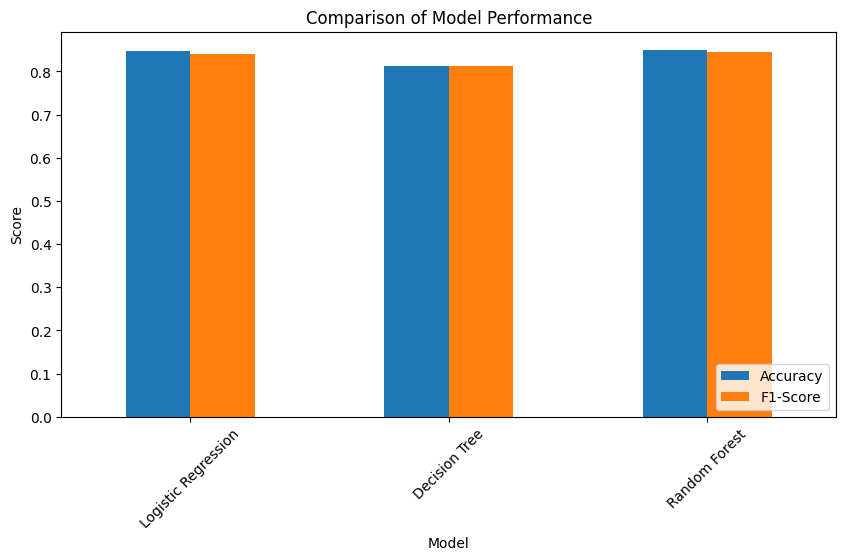

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# เตรียมข้อมูล: แปลง Categorical variables เป็นตัวเลข (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 1. กำหนดรายการโมเดลที่ต้องการทดสอบ
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
]

# 2. วนลูปเพื่อเทรนและเก็บค่าคะแนน
results = []
for name, model in models:
    # เทรนโมเดล (ใช้ X ตัวใหญ่ให้ตรงกับที่ประกาศไว้)
    model.fit(X_train, y_train)
    # ทำนายผล
    y_pred = model.predict(X_test)

    # เก็บค่า Accuracy และ F1-Score
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1})

# 3. แสดงผลในรูปแบบตารางเปรียบเทียบ
comparison_df = pd.DataFrame(results)
print(comparison_df.sort_values(by='F1-Score', ascending=False))

# 4. พล็อตกราฟเปรียบเทียบ
import matplotlib.pyplot as plt
comparison_df.set_index('Model')[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(10, 5))
plt.title('Comparison of Model Performance')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

In [22]:
import joblib
import os

# สร้างไดเรกทอรี 'model_artifacts' ถ้ายังไม่มี
os.makedirs('model_artifacts', exist_ok=True)

# เซฟโมเดลที่ดีที่สุด (แนะนำให้ใช้ตัวที่จูนแล้ว)
joblib.dump(full_pipeline, 'model_artifacts/salary_pipeline.pkl')

# เซฟรายชื่อคอลัมน์ไว้ใช้ในตอนทำเว็บ
import json
metadata = {'features': X.columns.tolist()}
with open('model_artifacts/model_metadata.json', 'w') as f:
    json.dump(metadata, f)